# 05 - Klasifikacija nivoa opterećenja

Do sada smo potražnju predviđali kao broj. U ovoj svesci isti problem postavljamo kao klasifikaciju: umesto tačnog broja iznajmljivanja, predviđamo da li je opterećenje sistema u datom satu nisko, srednje ili visoko.

Ovakva postavka ima praktičan smisao. Operateru sistema za preraspodelu bicikala nije potreban tačan broj, već informacija o tome koliko će stanice biti opterećene.

Učimo dva modela, multinomijalnu logističku regresiju i slučajnu šumu, i evaluiramo ih matricama konfuzije i klasifikacionim izveštajem.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn import preprocessing
from sklearn import linear_model
from sklearn import ensemble
from sklearn import metrics

np.random.seed(7)

# Učitavanje pripremljenih podataka

In [2]:
paket = joblib.load('../data/pripremljeno.joblib')

X = paket['X']
y = paket['y']
kolone = paket['kolone']

h_trening = paket['h_trening']
h_validacija = paket['h_validacija']
h_test = paket['h_test']

n_trening = paket['n_trening']
n_validacija = paket['n_validacija']
n_test = paket['n_test']

h_trening_validacija = h_trening | h_validacija

# Definisanje klasa

Broj iznajmljivanja delimo na tri nivoa opterećenja pomoću dva praga. Pragove biramo kao tercile ciljne promenljive, tako da svaka klasa u skupu za treniranje ima približno trećinu instanci.

Pragove računamo isključivo na skupu za treniranje, iz istog razloga iz kog i statistike za standardizaciju. Podaci iz skupa za testiranje ne smeju uticati ni na jednu odluku koja prethodi evaluaciji.

Podela je hronološka i preuzeta iz sveske 02, pa ovde nema stratifikacije po klasama kakva se u vežbama koristi uz nasumičnu podelu. Raspodelu klasa po skupovima zato proveravamo ručno.

In [3]:
prag_nisko, prag_visoko = np.quantile(y[h_trening], [1/3, 2/3])

print('prag između niskog i srednjeg opterećenja: ', round(prag_nisko))
print('prag između srednjeg i visokog opterećenja:', round(prag_visoko))

prag između niskog i srednjeg opterećenja:  56
prag između srednjeg i visokog opterećenja: 175


In [4]:
klasa = np.digitize(y, [prag_nisko, prag_visoko])

nazivi_klasa = ['nisko', 'srednje', 'visoko']

Funkcija np.digitize() svakoj vrednosti dodeljuje redni broj intervala u koji upada, pa dobijamo klase 0, 1 i 2.

Proveravamo raspodelu klasa po skupovima.

In [5]:
for naziv, maska in [('trening', h_trening), ('validacija', h_validacija), ('test', h_test)]:
    brojevi = np.bincount(klasa[maska])
    udeli = brojevi / maska.sum()
    print('%-11s %s   udeli: %s' % (naziv, brojevi, np.round(udeli, 3)))

trening     [2298 2292 2326]   udeli: [0.332 0.331 0.336]
validacija  [591 604 534]   udeli: [0.342 0.349 0.309]
test        [2222 1892 4620]   udeli: [0.254 0.217 0.529]


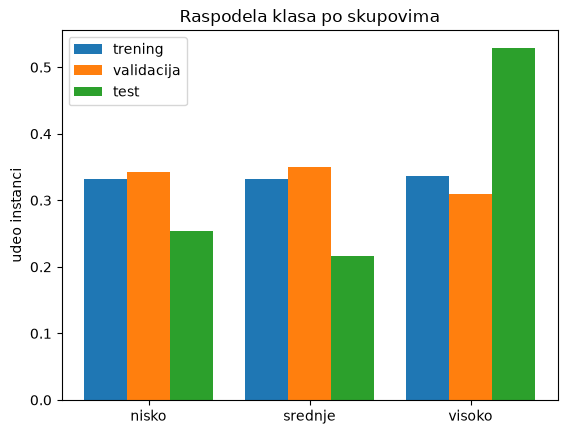

In [6]:
plt.hist([klasa[h_trening], klasa[h_validacija], klasa[h_test]],
         bins=[-0.5, 0.5, 1.5, 2.5],
         label=['trening', 'validacija', 'test'],
         density=True)

plt.xticks([0, 1, 2], labels=nazivi_klasa)
plt.ylabel('udeo instanci')
plt.title('Raspodela klasa po skupovima')
plt.legend()
plt.show()

Na skupu za treniranje klase su balansirane, jer su pragovi tako i izabrani. Na skupu za validaciju raspodela je slična.

Na skupu za testiranje više od polovine instanci pripada klasi visokog opterećenja. To nije greška u podeli, nego posledica rasta sistema. Skup za testiranje je 2012. godina, u kojoj je potražnja bila 1.65 puta veća, pa mnogo više sati prelazi prag koji je u 2011. označavao visoko opterećenje.

Ova neravnoteža ima dve posledice. Prvo, tačnost kao mera postaje manje pouzdana, pa uz nju računamo i F1 meru po klasama. Drugo, model koji je učio na balansiranim podacima suočiće se sa test skupom drugačije strukture, i to će se videti u matrici konfuzije.

# Standardizacija podataka

In [7]:
x_train = X[h_trening]
x_validation = X[h_validacija]
x_test = X[h_test]
x_train_validation = X[h_trening_validacija]

y_train = klasa[h_trening]
y_validation = klasa[h_validacija]
y_test = klasa[h_test]
y_train_validation = klasa[h_trening_validacija]

In [8]:
scaler = preprocessing.StandardScaler()
scaler.fit(x_train)

x_train_s = scaler.transform(x_train)
x_validation_s = scaler.transform(x_validation)

In [9]:
scaler_final = preprocessing.StandardScaler()
scaler_final.fit(x_train_validation)

x_train_validation_s = scaler_final.transform(x_train_validation)
x_test_s = scaler_final.transform(x_test)

# Funkcija za evaluaciju

Za svaki model ispisujemo tačnost, uprosečenu F1 meru i matricu konfuzije. F1 meru računamo za svaku od tri klase posebno, pa je uprosečimo.

In [10]:
def oceni(y_stvarno, y_predvidjeno, naziv):
    tacnost = metrics.accuracy_score(y_stvarno, y_predvidjeno)
    f1 = metrics.f1_score(y_stvarno, y_predvidjeno, average='macro')
    print('%-38s tačnost %.3f   F1 makro %.3f' % (naziv, tacnost, f1))
    return {'model': naziv, 'tačnost': tacnost, 'F1 makro': f1}

In [11]:
def prikazi_matricu(y_stvarno, y_predvidjeno, naslov):
    matrica = metrics.confusion_matrix(y_stvarno, y_predvidjeno)

    plt.figure(figsize=(5, 4))
    plt.imshow(matrica, cmap='Blues')
    plt.colorbar()

    for i in range(3):
        for j in range(3):
            plt.text(j, i, matrica[i, j], ha='center', va='center',
                     color='white' if matrica[i, j] > matrica.max() / 2 else 'black')

    plt.xticks([0, 1, 2], nazivi_klasa)
    plt.yticks([0, 1, 2], nazivi_klasa)
    plt.xlabel('predviđena klasa')
    plt.ylabel('stvarna klasa')
    plt.title(naslov)
    plt.show()

# Trivijalne osnove

Najjednostavnija osnova za klasifikaciju je model koji uvek predviđa najčešću klasu
iz skupa za treniranje.

In [12]:
vecinska_klasa = np.bincount(y_train_validation).argmax()

print('većinska klasa u treningu:', nazivi_klasa[vecinska_klasa])

rezultati = []
rezultati.append(oceni(y_test, np.full(len(y_test), vecinska_klasa), 'većinska klasa'))

većinska klasa u treningu: srednje
većinska klasa                         tačnost 0.217   F1 makro 0.119


Tačnost od 0.22 je manja od 0.33, koliko bi dalo nasumično pogađanje jedne od tri klase. Razlog je to što je najbrojnija klasa u treningu srednje opterećenje, a u testu visoko, pa model pogađa pogrešnu. I na ovome se vidi pomeraj između dve godine.

In [13]:
sat = pd.read_csv('../data/hour.csv')

prosek_po_satu = sat[h_trening_validacija].groupby(['hr', 'workingday'])['cnt'].mean()
kljucevi = sat[h_test].set_index(['hr', 'workingday']).index
osnova_broj = kljucevi.map(prosek_po_satu).to_numpy(dtype=float)
osnova_klasa = np.digitize(osnova_broj, [prag_nisko, prag_visoko])

rezultati.append(oceni(y_test, osnova_klasa, 'osnova po satu i tipu dana'))

osnova po satu i tipu dana             tačnost 0.711   F1 makro 0.714


Ova osnova pogađa nivo opterećenja u 71 odsto slučajeva, iako ne koristi nijedan vremenski atribut. Sat i tip dana dakle nose najveći deo informacije, isto kao i kod regresije.

# Multinomijalna logistička regresija

Logistička regresija se na više klasa uopštava tako što za svaku klasu uči po jedan skup koeficijenata, a predviđa se klasa sa najvećom verovatnoćom. U scikit-learn-u je to podrazumevano ponašanje klase LogisticRegression kada ciljna promenljiva ima više od dve klase.

Metaparametar koji podešavamo je regularizacioni parametar C. Manje vrednosti znače jaču regularizaciju. Biramo ga na skupu za validaciju.

In [14]:
Cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

In [15]:
best_score = 0
best_C = None
f1_po_C = []

for C in Cs:
    model = linear_model.LogisticRegression(C=C, max_iter=1000)
    model.fit(x_train_s, y_train)

    y_validation_predicted = model.predict(x_validation_s)
    score = metrics.f1_score(y_validation, y_validation_predicted, average='macro')
    f1_po_C.append(score)

    if score > best_score:
        best_score = score
        best_C = C

In [16]:
print('najbolje C:', best_C)
print('F1 makro na validaciji:', round(best_score, 3))

najbolje C: 0.001
F1 makro na validaciji: 0.699


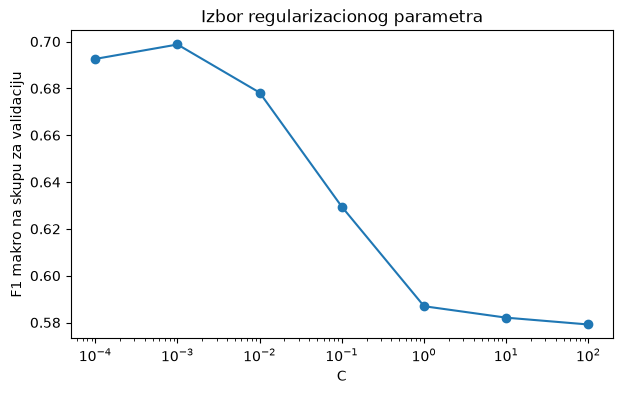

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(Cs, f1_po_C, marker='o')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('F1 makro na skupu za validaciju')
plt.title('Izbor regularizacionog parametra')
plt.show()

Najbolje rezultate daje jaka regularizacija, C = 0.001. Sa još jačom, C = 0.0001, rezultat
ponovo opada, pa je optimum unutar ispitanog opsega, a ne na njegovoj ivici. Sa pedeset dva atributa, od kojih su
mnogi one-hot kodirani, model bez regularizacije lako prilagodi koeficijente
pojedinačnim kombinacijama iz treninga koje se u validaciji ne ponavljaju.

Konačni model obučavamo na uniji treninga i validacije.

In [18]:
model_logisticka = linear_model.LogisticRegression(C=best_C, max_iter=1000)
model_logisticka.fit(x_train_validation_s, y_train_validation)

LogisticRegression(C=0.001, max_iter=1000)

In [19]:
y_test_predicted_logisticka = model_logisticka.predict(x_test_s)

rezultati.append(oceni(y_test, y_test_predicted_logisticka, 'multinomijalna logistička regresija'))

multinomijalna logistička regresija    tačnost 0.698   F1 makro 0.687


In [20]:
print(metrics.classification_report(y_test, y_test_predicted_logisticka,
                                    target_names=nazivi_klasa, digits=3))

              precision    recall  f1-score   support

       nisko      0.776     0.887     0.828      2222
     srednje      0.405     0.612     0.487      1892
      visoko      0.892     0.643     0.747      4620

    accuracy                          0.698      8734
   macro avg      0.691     0.714     0.687      8734
weighted avg      0.757     0.698     0.711      8734



In [21]:
metrics.confusion_matrix(y_test, y_test_predicted_logisticka)

array([[1972,  176,   74],
       [ 447, 1158,  287],
       [ 123, 1528, 2969]])

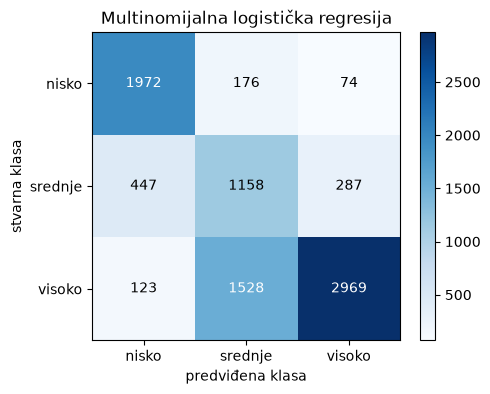

In [22]:
prikazi_matricu(y_test, y_test_predicted_logisticka, 'Multinomijalna logistička regresija')

Matrica konfuzije pokazuje gde model greši. Redovi su stvarne klase, kolone predviđene.

Nisko opterećenje model prepoznaje dobro, sa odzivom oko 0.9. Visoko opterećenje prepoznaje sa odzivom svega oko 0.64, a najveći broj grešaka je u ćeliji gde je stvarna klasa visoko a predviđena srednje.

To je isti efekat koji smo kod regresije videli kao negativno sistematsko odstupanje. Model je naučio nivoe iz 2011. godine, pa sate koji su u 2012. visoko opterećeni svrstava u srednje. Preciznost za klasu visoko je zato visoka, oko 0.9: kada model kaže da je opterećenje visoko, uglavnom je u pravu, ali to kaže ređe nego što bi trebalo.

# Slučajna šuma kao klasifikator

Slučajnu šumu koristimo i za klasifikaciju. Razlika u odnosu na regresiju je u tome
što se o konačnoj klasi odlučuje većinskim glasanjem stabala umesto uprosečavanjem.

Podešavamo maksimalnu dubinu stabla, a broj stabala držimo na sto, pošto smo u svesci 04
videli da u tom opsegu ne pravi razliku.

In [23]:
dubine = [10, 20, None]

In [24]:
best_score = 0
best_depth = None
f1_po_dubini = []

for d in dubine:
    model = ensemble.RandomForestClassifier(n_estimators=100, max_depth=d, random_state=7)
    model.fit(x_train, y_train)

    y_validation_predicted = model.predict(x_validation)
    score = metrics.f1_score(y_validation, y_validation_predicted, average='macro')
    f1_po_dubini.append(score)

    if score > best_score:
        best_score = score
        best_depth = d

In [25]:
print('najbolja dubina:', best_depth)
print('F1 makro na validaciji:', round(best_score, 3))

najbolja dubina: None
F1 makro na validaciji: 0.675


In [26]:
model_forest = ensemble.RandomForestClassifier(n_estimators=100, max_depth=best_depth, random_state=7)
model_forest.fit(x_train_validation, y_train_validation)

RandomForestClassifier(random_state=7)

In [27]:
y_test_predicted_forest = model_forest.predict(x_test)

rezultati.append(oceni(y_test, y_test_predicted_forest, 'slučajna šuma'))

slučajna šuma                          tačnost 0.722   F1 makro 0.711


In [28]:
print(metrics.classification_report(y_test, y_test_predicted_forest,
                                    target_names=nazivi_klasa, digits=3))

              precision    recall  f1-score   support

       nisko      0.781     0.922     0.846      2222
     srednje      0.421     0.657     0.513      1892
      visoko      0.954     0.653     0.775      4620

    accuracy                          0.722      8734
   macro avg      0.719     0.744     0.711      8734
weighted avg      0.795     0.722     0.736      8734



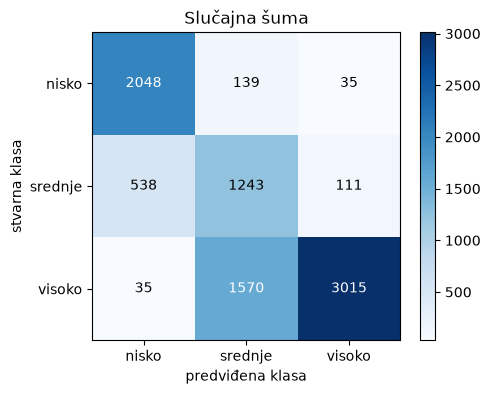

In [29]:
prikazi_matricu(y_test, y_test_predicted_forest, 'Slučajna šuma')

Slučajna šuma je nešto bolja od logističke regresije, ali je obrazac grešaka isti. Gotovo sve greške su u istoj ćeliji, visoko opterećenje predviđeno kao srednje.

U poređenju sa osnovom po satu i tipu dana, šuma je bolja tek za oko jedan procentni poen tačnosti, a po F1 meri su izjednačene, osnova je čak za tri hiljadita ispred (0.714 naspram 0.711). Kod ovako grubih klasa najveći deo informacije nosi upravo sat i tip dana, a ono što modeli dodatno nauče iz vremenskih uslova ne donosi merljiv dobitak.

# Poređenje sa nasumičnom podelom

In [30]:
n_trening_validacija = n_trening | n_validacija

scaler_n = preprocessing.StandardScaler()
scaler_n.fit(X[n_trening_validacija])

model_logisticka_n = linear_model.LogisticRegression(C=best_C, max_iter=1000)
model_logisticka_n.fit(scaler_n.transform(X[n_trening_validacija]), klasa[n_trening_validacija])

model_forest_n = ensemble.RandomForestClassifier(n_estimators=100, max_depth=best_depth, random_state=7)
model_forest_n.fit(X[n_trening_validacija], klasa[n_trening_validacija])

RandomForestClassifier(random_state=7)

In [31]:
oceni(klasa[n_test], model_logisticka_n.predict(scaler_n.transform(X[n_test])), 'logistička, nasumična podela')
oceni(y_test, y_test_predicted_logisticka, 'logistička, hronološka podela')
print()
oceni(klasa[n_test], model_forest_n.predict(X[n_test]), 'šuma, nasumična podela')
oceni(y_test, y_test_predicted_forest, 'šuma, hronološka podela')
print()

logistička, nasumična podela           tačnost 0.756   F1 makro 0.732
logistička, hronološka podela          tačnost 0.698   F1 makro 0.687

šuma, nasumična podela                 tačnost 0.845   F1 makro 0.836
šuma, hronološka podela                tačnost 0.722   F1 makro 0.711



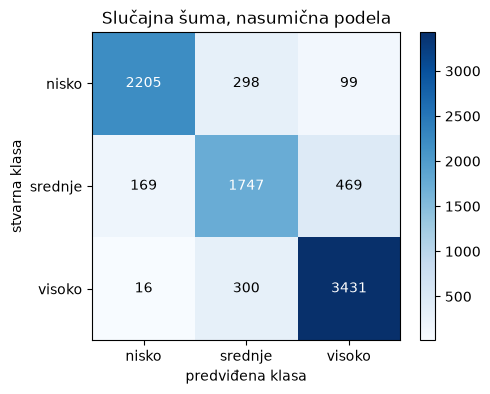

In [32]:
prikazi_matricu(klasa[n_test], model_forest_n.predict(X[n_test]), 'Slučajna šuma, nasumična podela')

Na nasumičnoj podeli šuma ima tačnost oko 0.85, a na hronološkoj oko 0.72. Matrica konfuzije na nasumičnoj podeli je gotovo simetrična, bez izraženog pomeraja ka nižim klasama, jer je model već tokom obučavanja video sate iz 2012. godine.

Razlika između dve podele je ista kao kod regresije, samo se ovde vidi kroz raspodelu grešaka po klasama umesto kroz sistematsko odstupanje.

# Zbirni prikaz

In [33]:
tabela_rezultata = pd.DataFrame(rezultati).set_index('model')
tabela_rezultata.round(3)

,tačnost,F1 makro
model,,
većinska klasa,0.217,0.119
osnova po satu i tipu dana,0.711,0.714
multinomijalna logistička regresija,0.698,0.687
slučajna šuma,0.722,0.711


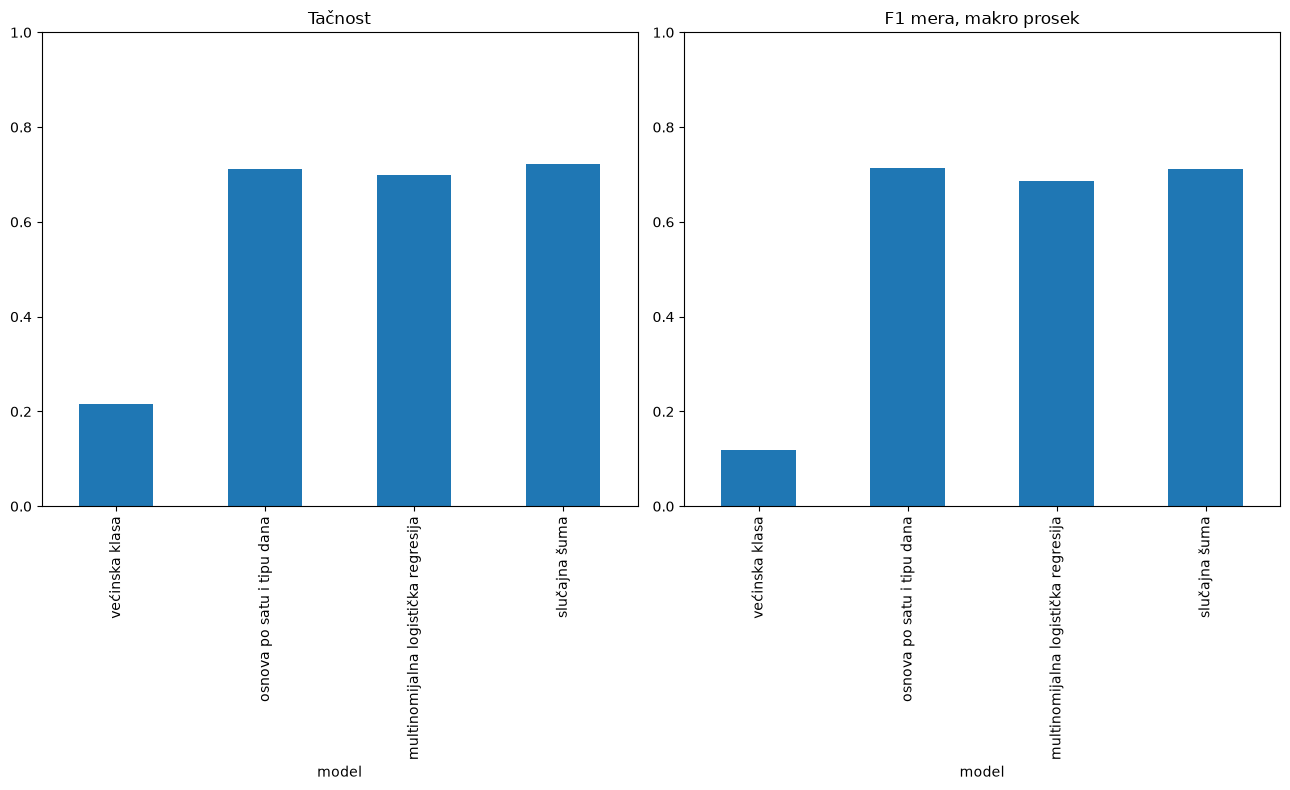

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(13, 8))

tabela_rezultata['tačnost'].plot(kind='bar', ax=ax[0])
ax[0].set_title('Tačnost')
ax[0].set_ylim(0, 1)

tabela_rezultata['F1 makro'].plot(kind='bar', ax=ax[1])
ax[1].set_title('F1 mera, makro prosek')
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Čuvanje modela

Uz modele čuvamo i pragove, jer bez njih model ne može da se primeni na nove podatke.

In [35]:
joblib.dump(model_logisticka, '../models/05_logisticka_regresija.joblib')
joblib.dump(model_forest, '../models/05_slucajna_suma_klasifikator.joblib')
joblib.dump(scaler_final, '../models/05_scaler.joblib')
joblib.dump({'prag_nisko': prag_nisko, 'prag_visoko': prag_visoko, 'nazivi': nazivi_klasa},
            '../models/05_pragovi.joblib')

tabela_rezultata.to_csv('../models/05_rezultati.csv')

print('sačuvano')

sačuvano


# Zaključci

1. Pragovi za klase su izabrani kao tercili skupa za treniranje. Na skupu za testiranje
   više od polovine sati pripada klasi visokog opterećenja, što je direktna posledica
   rasta sistema između dve godine.

2. Osnova koja predviđa klasu iz proseka za sat i tip dana pogađa u 71 odsto slučajeva.
   Multinomijalna logistička regresija je nešto ispod tog nivoa, a slučajna šuma je za tek malo
   iznad njega.

3. Matrice konfuzije oba modela imaju isti obrazac: nisko opterećenje se prepoznaje
   gotovo bez greške, a visoko se u trećini slučajeva svrstava u srednje. To je
   klasifikaciona slika istog potcenjivanja koje smo kod regresije videli
   kao negativno odstupanje.

4. Logističkoj regresiji najviše odgovara jaka regularizacija, jer sa pedeset dva
   atributa bez nje prilagođava koeficijente kombinacijama koje se ne ponavljaju.

5. Nasumična podela daje tačnost 0.85 naspram 0.72, sa gotovo simetričnom matricom
   konfuzije, jer pušta 2012. godinu u trening.
